# ChoiceIQ Notebook 1 — Data Preprocessing & Feature Engineering

This notebook documents how the raw ESCO files are transformed into the processed career feature matrix used by the recommender.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
BASE = Path('..').resolve()
RAW = BASE/'Data'/'raw'
PROC = BASE/'Data'/'processed'
print('Project root:', BASE)

Project root: C:\Users\gugun\Desktop\ChoiceIQ Project\ChoiceIQ_Final_Project


In [2]:
occ = pd.read_csv(RAW/'occupations_en.csv')
rel = pd.read_csv(RAW/'occupationSkillRelations_en.csv')
print('Occupations:', occ.shape)
print('Occupation-skill relations:', rel.shape)
occ.head(3)

Occupations: (3043, 15)
Occupation-skill relations: (126051, 6)


,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,naceCode
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,director of technical arts\ntechnical supervis...,NaN,released,2024-01-25T11:28:50.295Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Technical directors realise the artistic visio...,2654.1.7,http://data.europa.eu/ux2/nace2.1/9031
1,Occupation,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,wire drawer\nforming machine operative\ndraw m...,NaN,released,2024-01-23T10:09:32.099Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Metal drawing machine operators set up and ope...,8121.4,http://data.europa.eu/ux2/nace2.1/242
2,Occupation,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,precision device quality control supervisor\np...,NaN,released,2024-01-25T15:00:12.188Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Precision device inspectors make sure precisio...,7543.10.3,http://data.europa.eu/ux2/nace2.1/2651


## 1. Data Cleaning and Preprocessing

This section makes the cleaning process explicit instead of hiding it inside `build_career_dataset.py`.

The raw ESCO files are inspected for missing values, duplicates, inconsistent text formatting, irrelevant records, and non-ICT occupations before feature engineering.

In [3]:
# Load only the columns required by ChoiceIQ
occ_raw = pd.read_csv(RAW/'occupations_en.csv', usecols=['conceptUri','iscoGroup','preferredLabel','description','code'])
rel_raw = pd.read_csv(RAW/'occupationSkillRelations_en.csv', usecols=['occupationUri','occupationLabel','relationType','skillLabel'])

print('RAW DATA SHAPES')
print('Occupations:', occ_raw.shape)
print('Occupation-skill relations:', rel_raw.shape)
display(occ_raw.head(3))
display(rel_raw.head(3))

RAW DATA SHAPES
Occupations: (3043, 5)
Occupation-skill relations: (126051, 4)


,conceptUri,iscoGroup,preferredLabel,description,code
0,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,Technical directors realise the artistic visio...,2654.1.7
1,http://data.europa.eu/esco/occupation/000e93a3...,8121,metal drawing machine operator,Metal drawing machine operators set up and ope...,8121.4
2,http://data.europa.eu/esco/occupation/0019b951...,7543,precision device inspector,Precision device inspectors make sure precisio...,7543.10.3


,occupationUri,occupationLabel,relationType,skillLabel
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,write risk assessment on performing arts produ...


In [4]:
# Check missing values before cleaning
print('MISSING VALUES - OCCUPATIONS')
display(occ_raw.isna().sum().to_frame('missing_values'))

print('MISSING VALUES - OCCUPATION-SKILL RELATIONS')
display(rel_raw.isna().sum().to_frame('missing_values'))

MISSING VALUES - OCCUPATIONS


,missing_values
conceptUri,0
iscoGroup,0
preferredLabel,0
description,0
code,0


MISSING VALUES - OCCUPATION-SKILL RELATIONS


,missing_values
occupationUri,0
occupationLabel,0
relationType,0
skillLabel,0


In [5]:
# Check duplicates before cleaning
print('Duplicate occupation conceptUri values:', occ_raw.duplicated(subset='conceptUri').sum())
print('Exact duplicate occupation-skill relation rows:', rel_raw.duplicated().sum())

Duplicate occupation conceptUri values: 4
Exact duplicate occupation-skill relation rows: 0


### Cleaning decisions

- Required occupation fields: `conceptUri`, `preferredLabel`, `iscoGroup`.
- Required relationship fields: `occupationUri`, `relationType`, `skillLabel`.
- Missing descriptions are allowed because descriptions are supporting evidence, not the only data source.
- Duplicate occupations are removed using `conceptUri`.
- Exact duplicate skill-relation rows are removed.
- Text is stripped and standardized.
- `relationType` and `skillLabel` are converted to lowercase for consistent keyword matching.
- `iscoGroup` is converted to string before filtering.

In [6]:
# Create cleaned copies so raw data remains untouched
occ_clean = occ_raw.copy()
rel_clean = rel_raw.copy()

# 1. Remove records missing fields required by the pipeline
occ_clean = occ_clean.dropna(subset=['conceptUri','preferredLabel','iscoGroup']).copy()
rel_clean = rel_clean.dropna(subset=['occupationUri','relationType','skillLabel']).copy()

# 2. Remove duplicates
occ_clean = occ_clean.drop_duplicates(subset='conceptUri').copy()
rel_clean = rel_clean.drop_duplicates().copy()

# 3. Standardise text fields
occ_clean['preferredLabel'] = occ_clean['preferredLabel'].astype(str).str.strip()
occ_clean['iscoGroup'] = occ_clean['iscoGroup'].astype(str).str.strip()
occ_clean['description_clean'] = occ_clean['description'].fillna('').astype(str).str.strip().str.lower()

rel_clean['occupationLabel'] = rel_clean['occupationLabel'].fillna('').astype(str).str.strip()
rel_clean['relationType'] = rel_clean['relationType'].astype(str).str.strip().str.lower()
rel_clean['skillLabel'] = rel_clean['skillLabel'].astype(str).str.strip().str.lower()

print('CLEANED DATA SHAPES')
print('Occupations:', occ_clean.shape)
print('Occupation-skill relations:', rel_clean.shape)

CLEANED DATA SHAPES
Occupations: (3039, 6)
Occupation-skill relations: (126051, 4)


In [7]:
# Before/after cleaning summary
cleaning_summary = pd.DataFrame({
    'dataset': ['Occupations','Occupation-skill relations'],
    'rows_before': [len(occ_raw), len(rel_raw)],
    'rows_after': [len(occ_clean), len(rel_clean)]
})
cleaning_summary['rows_removed'] = cleaning_summary['rows_before'] - cleaning_summary['rows_after']
display(cleaning_summary)

print('Remaining missing values in required occupation fields:')
display(occ_clean[['conceptUri','preferredLabel','iscoGroup']].isna().sum().to_frame('missing_values'))

print('Remaining missing values in required relationship fields:')
display(rel_clean[['occupationUri','relationType','skillLabel']].isna().sum().to_frame('missing_values'))

,dataset,rows_before,rows_after,rows_removed
0,Occupations,3043,3039,4
1,Occupation-skill relations,126051,126051,0


Remaining missing values in required occupation fields:


,missing_values
conceptUri,0
preferredLabel,0
iscoGroup,0


Remaining missing values in required relationship fields:


,missing_values
occupationUri,0
relationType,0
skillLabel,0


## 2. ICT Career Filtering

After cleaning, ChoiceIQ narrows ESCO to the ICT domain. The production logic keeps occupations whose ISCO group starts with `25`, `351`, or `3522`, then applies a curated list of 30 ICT career titles.

In [8]:
PREFERRED = [
    'data analyst','data scientist','data engineer','software developer','web developer',
    'mobile application developer','artificial intelligence engineer','computer scientist',
    'ICT business analyst','ICT system analyst','ICT system architect','cloud engineer',
    'cloud architect','cloud DevOps engineer','database administrator','database developer',
    'ICT network administrator','ICT network architect','ICT network engineer',
    'ICT system administrator','ICT security administrator','cyber incident responder',
    'cybersecurity risk manager','digital forensics expert','ethical hacker',
    'ICT security technician','ICT help desk agent','ICT technician','software tester',
    'user interface designer'
]

ict_pool = occ_clean[occ_clean['iscoGroup'].str.startswith(('25','351','3522'))].copy()
ict_selected = ict_pool[ict_pool['preferredLabel'].isin(PREFERRED)].drop_duplicates('conceptUri').copy()
rels_selected = rel_clean[rel_clean['occupationUri'].isin(ict_selected['conceptUri'])].copy()

print('All cleaned occupations:', len(occ_clean))
print('ICT occupations after ISCO filtering:', len(ict_pool))
print('Final selected ICT careers:', len(ict_selected))
print('Skill relationships retained:', len(rels_selected))

display(ict_selected[['preferredLabel','iscoGroup','code']].sort_values('preferredLabel').reset_index(drop=True))

All cleaned occupations: 3039
ICT occupations after ISCO filtering: 84
Final selected ICT careers: 30
Skill relationships retained: 2221


,preferredLabel,iscoGroup,code
0,ICT business analyst,2511,2511.9
1,ICT help desk agent,3512,3512.1
2,ICT network administrator,2522,2522.1.1
3,ICT network architect,2523,2523.2
4,ICT network engineer,2523,2523.3
5,ICT security administrator,2529,2529.6
6,ICT security technician,3512,3512.3
7,ICT system administrator,2522,2522.1
8,ICT system analyst,2511,2511.13
9,ICT system architect,2511,2511.14


## 3. Skill Evidence Preparation

Essential skills receive weight `1.0`; optional skills receive weight `0.55`. This makes essential career skills contribute more strongly to the final feature profile.

In [9]:
display(rels_selected['relationType'].value_counts().to_frame('count'))

example_uri = ict_selected.loc[ict_selected['preferredLabel'].eq('data scientist'),'conceptUri']
if len(example_uri):
    display(rels_selected[rels_selected['occupationUri'].eq(example_uri.iloc[0])][['occupationLabel','relationType','skillLabel']].head(15))

,count
relationType,
optional,1398
essential,823


,occupationLabel,relationType,skillLabel
19748,data scientist,essential,mathematical modelling
19749,data scientist,essential,data mining
19750,data scientist,essential,visual presentation techniques
19751,data scientist,essential,data engineering
19752,data scientist,essential,quantitative analysis
19753,data scientist,essential,data visualisation software
19754,data scientist,essential,statistical modeling techniques
19755,data scientist,essential,information extraction
19756,data scientist,essential,scientific literature
19757,data scientist,essential,statistics


## 4. Feature Engineering

The cleaned skill text, occupation descriptions, and transparent title-based priors are transformed into the nine features used by the recommender: data analytics, programming, mathematics, cybersecurity, networking, problem solving, creativity/design, systems/cloud, and communication/business.

## 5. Inspect the Engineered Features
All careers and user quiz responses are represented in the same nine-dimensional feature space.

In [10]:
processed = pd.read_csv(PROC/'choiceiq_careers.csv')
print('Processed model-ready careers:', processed.shape[0])
display(processed[['career','esco_code','essential_skill_count','optional_skill_count']].head(10))

Processed model-ready careers: 30


,career,esco_code,essential_skill_count,optional_skill_count
0,Artificial Intelligence Engineer,2511.11,31,58
1,Cloud Architect,2512.6,6,11
2,Cloud Devops Engineer,2512.7,24,6
3,Cloud Engineer,2512.1,33,12
4,Computer Scientist,2511.1,45,45
5,Cyber Incident Responder,2529.7,23,52
6,Cybersecurity Risk Manager,2529.8,22,50
7,Data Analyst,2511.3,36,31
8,Data Engineer,2511.20,23,5
9,Data Scientist,2511.4,63,34


In [11]:
FEATURES=['data_analytics','programming','mathematics','cybersecurity','networking','problem_solving','creativity_design','systems_cloud','communication_business']
processed[FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
data_analytics,30.0,0.189260,0.278437,0.0000,0.018175,0.05145,0.211225,1.0
programming,30.0,0.337973,0.332480,0.0000,0.031450,0.25990,0.581150,1.0
mathematics,30.0,0.135037,0.260385,0.0000,0.000000,0.00000,0.129575,1.0
cybersecurity,30.0,0.217613,0.320811,0.0000,0.022300,0.06280,0.217600,1.0
networking,30.0,0.167513,0.242349,0.0000,0.008625,0.09720,0.192050,1.0
problem_solving,30.0,0.421360,0.261551,0.0000,0.223800,0.36090,0.537275,1.0
creativity_design,30.0,0.274750,0.248960,0.0000,0.062525,0.22200,0.447775,1.0
systems_cloud,30.0,0.369347,0.265884,0.0226,0.187375,0.29570,0.438925,1.0
communication_business,30.0,0.258383,0.195882,0.0000,0.174975,0.23030,0.316675,1.0


## 6. South African Validation
The validation columns are metadata based on the supplied official South African High Demand and Critical Skills documents. They do not change the similarity score.

In [12]:
processed[['career','sa_validation_status','sa_official_match','sa_high_demand_2024','sa_critical_skills_2023']].head(15)

,career,sa_validation_status,sa_official_match,sa_high_demand_2024,sa_critical_skills_2023
0,Artificial Intelligence Engineer,Not directly matched in supplied lists,NaN,False,False
1,Cloud Architect,Related official occupation,Computer Network and Systems Engineer,True,True
2,Cloud Devops Engineer,Related official occupation,Computer Network and Systems Engineer / System...,True,True
3,Cloud Engineer,Related official occupation,Computer Network and Systems Engineer,True,True
4,Computer Scientist,Not directly matched in supplied lists,NaN,False,False
5,Cyber Incident Responder,Related official occupation,ICT Security Specialist,True,True
6,Cybersecurity Risk Manager,Related official occupation,ICT Security Specialist,True,True
7,Data Analyst,Not directly matched in supplied lists,NaN,False,False
8,Data Engineer,Not directly matched in supplied lists,NaN,False,False
9,Data Scientist,Exact official occupation,Data Scientist,True,True


## 7. Rebuild the Dataset
Run the cell below whenever the raw ESCO data or feature-engineering rules change.

In [13]:
import subprocess, sys
result = subprocess.run([sys.executable, str(BASE/'build_career_dataset.py')], cwd=BASE, capture_output=True, text=True)
print(result.stdout)
if result.stderr: print(result.stderr)

Created 30 careers with 9 engineered features



### Output files
- `Data/processed/choiceiq_careers.csv`
- `Data/processed/choiceiq_skill_evidence.csv`
- `Data/processed/south_africa_validation.csv`

## 8. Exploratory Data Analysis and Report Visuals

These cells reproduce the main visuals used in the Data Analysis Report and final presentation.

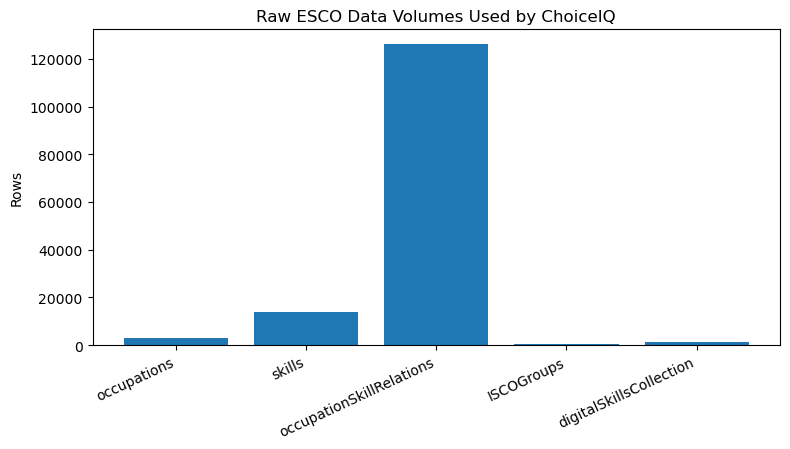

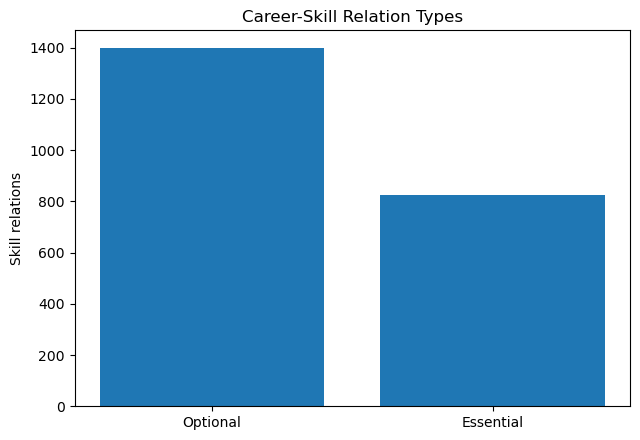

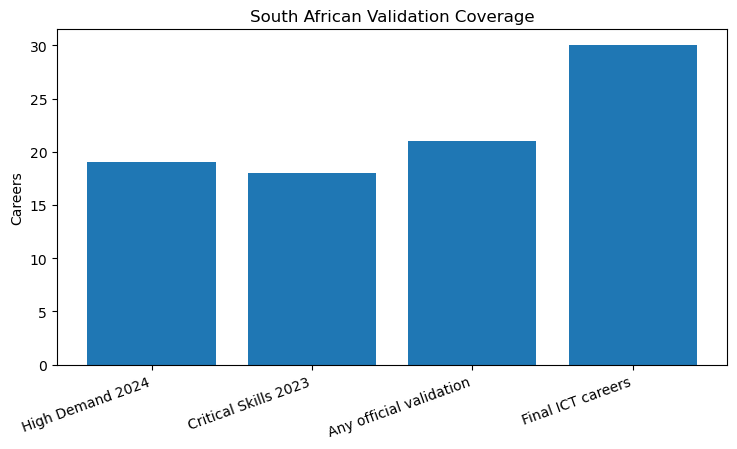

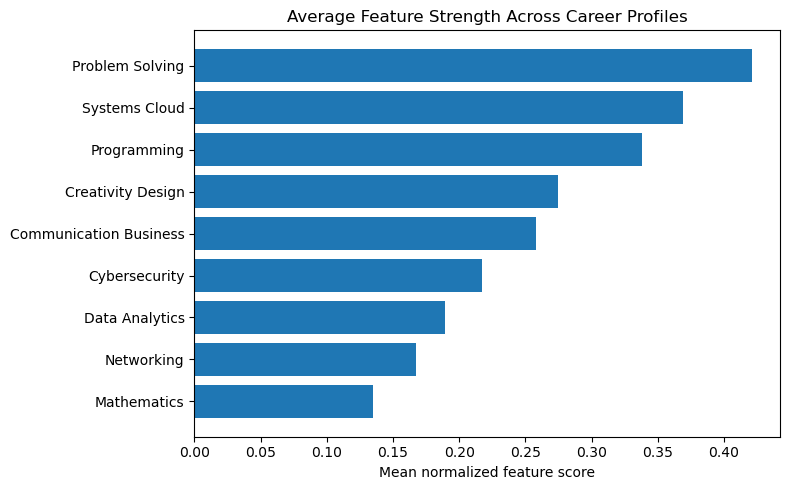

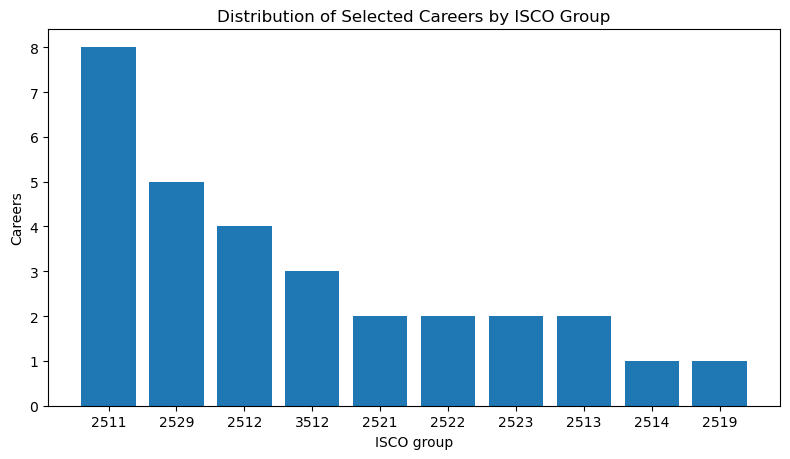

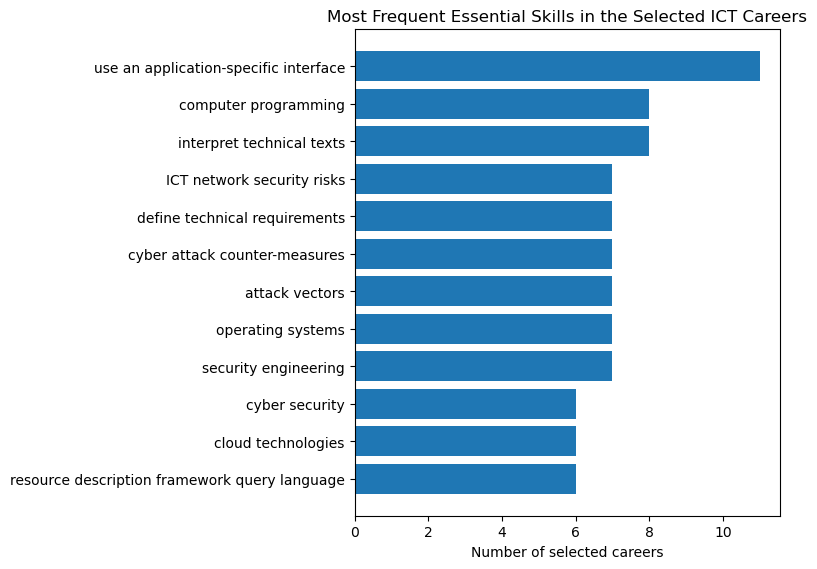

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
FIG = BASE/'assets'/'figures'
FIG.mkdir(parents=True, exist_ok=True)
careers = pd.read_csv(PROC/'choiceiq_careers.csv')
skill_evidence = pd.read_csv(PROC/'choiceiq_skill_evidence.csv')
raw_counts = {}
for filename in ['occupations_en.csv','skills_en.csv','occupationSkillRelations_en.csv','ISCOGroups_en.csv','digitalSkillsCollection_en.csv']:
    df_tmp = pd.read_csv(RAW/filename)
    raw_counts[filename.replace('_en.csv','').replace('.csv','')] = len(df_tmp)
plt.figure(figsize=(8,4.6)); plt.bar(raw_counts.keys(), raw_counts.values()); plt.xticks(rotation=25, ha='right'); plt.ylabel('Rows'); plt.title('Raw ESCO Data Volumes Used by ChoiceIQ'); plt.tight_layout(); plt.savefig(FIG/'01_raw_data_counts.png',dpi=160); plt.show()
relation_counts=skill_evidence['relationType'].value_counts(); plt.figure(figsize=(6.5,4.5)); plt.bar(relation_counts.index.str.title(),relation_counts.values); plt.ylabel('Skill relations'); plt.title('Career-Skill Relation Types'); plt.tight_layout(); plt.savefig(FIG/'02_relation_types.png',dpi=160); plt.show()
validation_counts=pd.Series({'High Demand 2024':int(careers['sa_high_demand_2024'].sum()),'Critical Skills 2023':int(careers['sa_critical_skills_2023'].sum()),'Any official validation':int(careers['sa_any_validation'].sum()),'Final ICT careers':len(careers)}); plt.figure(figsize=(7.5,4.6)); plt.bar(validation_counts.index,validation_counts.values); plt.ylabel('Careers'); plt.title('South African Validation Coverage'); plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.savefig(FIG/'03_sa_validation.png',dpi=160); plt.show()
feature_cols=['data_analytics','programming','mathematics','cybersecurity','networking','problem_solving','creativity_design','systems_cloud','communication_business']; feature_means=careers[feature_cols].mean().sort_values(); plt.figure(figsize=(8,5)); plt.barh(feature_means.index.str.replace('_',' ').str.title(),feature_means.values); plt.xlabel('Mean normalized feature score'); plt.title('Average Feature Strength Across Career Profiles'); plt.tight_layout(); plt.savefig(FIG/'04_feature_means.png',dpi=160); plt.show()
isc=careers['isco_group'].astype(str).value_counts().sort_values(ascending=False); plt.figure(figsize=(8,4.7)); plt.bar(isc.index,isc.values); plt.xlabel('ISCO group'); plt.ylabel('Careers'); plt.title('Distribution of Selected Careers by ISCO Group'); plt.tight_layout(); plt.savefig(FIG/'05_isco_distribution.png',dpi=160); plt.show()
essential=skill_evidence[skill_evidence['relationType'].astype(str).str.lower().eq('essential')]; top_skills=essential['skillLabel'].value_counts().head(12).sort_values(); plt.figure(figsize=(8,5.8)); plt.barh(top_skills.index,top_skills.values); plt.xlabel('Number of selected careers'); plt.title('Most Frequent Essential Skills in the Selected ICT Careers'); plt.tight_layout(); plt.savefig(FIG/'06_top_essential_skills.png',dpi=160); plt.show()

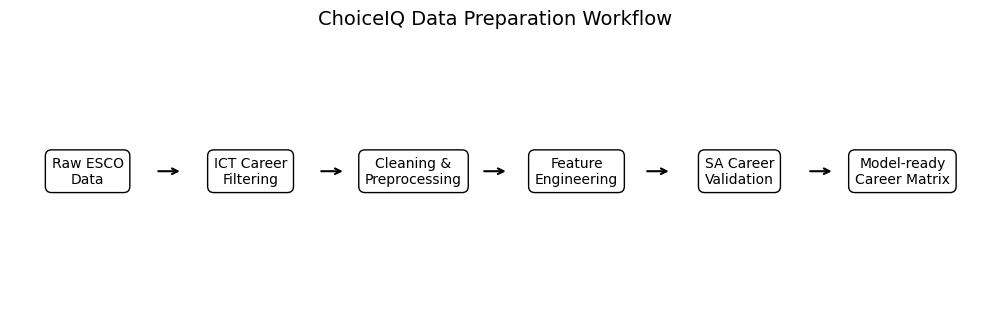

In [15]:
fig,ax=plt.subplots(figsize=(10,3.2)); ax.axis('off'); steps=['Raw ESCO\nData','ICT Career\nFiltering','Cleaning &\nPreprocessing','Feature\nEngineering','SA Career\nValidation','Model-ready\nCareer Matrix']; x=np.linspace(0.08,0.92,len(steps))
for i,(xi,step) in enumerate(zip(x,steps)):
    ax.text(xi,0.5,step,ha='center',va='center',bbox=dict(boxstyle='round,pad=0.45',fc='white',ec='black'))
    if i<len(steps)-1: ax.annotate('',xy=(x[i+1]-0.07,0.5),xytext=(xi+0.07,0.5),arrowprops=dict(arrowstyle='->',lw=1.5))
ax.set_title('ChoiceIQ Data Preparation Workflow',pad=14,fontsize=14); plt.tight_layout(); plt.savefig(FIG/'07_workflow.png',dpi=160,bbox_inches='tight'); plt.show()